In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics.pairwise import cosine_similarity

import jax
from darnax.modules.conv.conv import Conv2D, Conv2DRecurrentDiscrete
from darnax.modules.conv.pooling import GlobalUnpooling, GlobalMajorityPooling
from darnax.modules.fully_connected import FullyConnected, FrozenRescaledFullyConnected
from darnax.modules.recurrent import RecurrentDiscrete
from darnax.modules.input_output import OutputLayer


from darnax.layer_maps.sparse import LayerMap
from darnax.states.sequential import SequentialState
from darnax.orchestrators.sequential import SequentialOrchestrator
from darnax.datasets.classification.cifar10 import Cifar10

import equinox as eqx
import jax.tree_util as jtu
import optax
import jax.numpy as jnp


## Importing the dataset (CIFAR)

In [11]:
data = Cifar10(batch_size=32, linear_projection=None, label_mode="pm1", x_transform="identity")
key = jax.random.PRNGKey(0)
key, dk = jax.random.split(key)
data.build(key=dk)

it = iter(data)
x_A, y_A = next(it)
next(it)
x_B, y_B = next(it)

if x_A.ndim == 2: x_A = x_A.reshape(x_A.shape[0], 32, 32, 3)
if x_B.ndim == 2: x_B = x_B.reshape(x_B.shape[0], 32, 32, 3)

x_A = (x_A - x_A.mean()) / x_A.std()
x_B = (x_B - x_B.mean()) / x_B.std()

x_A1, y_A1 = x_A[0:1], y_A[0:1]
x_B1, y_B1 = x_B[0:1], y_B[0:1]

print(f"Single image A: {x_A1.shape}  label: {np.argmax(np.array(y_A1))}")
print(f"Single image B: {x_B1.shape}  label: {np.argmax(np.array(y_B1))}")

Single image A: (1, 32, 32, 3)  label: 3
Single image B: (1, 32, 32, 3)  label: 4


## Model — build the simplest possible architecture

One hidden layer. No convolution. Inputs fed via a fixed (non-trainable) fully-connected layer.
The only trainable weights are the recurrent couplings **J** inside `RecurrentDiscrete`.

For Stages A–B we include an output readout layer, but Stage A ignores it.


In [15]:
# ── Hyperparameters ────────────────────────────────────────────────────────
DIM_IN      = 32 * 32 * 3   # flattened CIFAR image
DIM_HIDDEN  = 512            # hidden neurons
NUM_LABELS  = 10             # output classes

# Core hyperparameters of interest
J_D         = 0.0    # self-coupling diagonal
THRESHOLD   = 0.5    # per-unit margin threshold (kappa)
LR          = 0.01   # learning rate for Optax (Adam)
STRENGTH_IN = 1.0    # scale of input→hidden weights
STRENGTH_OUT= 1.0    # scale of hidden→output weights

T_WARMUP    = 5      # warmup steps (free, random init)
T_CLAMP     = 10     # clamped phase steps (labels visible)
T_FREE      = 10     # free phase steps
N_UPDATES   = 60     # total Hebbian updates to run

# ── Flatten helper ─────────────────────────────────────────────────────────
def flatten(x):
    """(B, H, W, C) → (B, H*W*C) float32."""
    return x.reshape(x.shape[0], -1).astype(jnp.float32)

x_A_flat = flatten(x_A1)   # shape (1, 3072)
x_B_flat = flatten(x_B1)

print(f"x_A_flat: {x_A_flat.shape}  label_A: {int(jnp.argmax(y_A1))}")
print(f"x_B_flat: {x_B_flat.shape}  label_B: {int(jnp.argmax(y_B1))}")


x_A_flat: (1, 3072)  label_A: 3
x_B_flat: (1, 3072)  label_B: 4


In [ ]:
def build_model(key, j_d=J_D, threshold=THRESHOLD, strength_in=STRENGTH_IN, strength_out=STRENGTH_OUT):
    """Return (state, orchestrator, optimizer, opt_state) for the simplest FC-recurrent network."""
    keys = jax.random.split(key, 4)

    state = SequentialState((DIM_IN, DIM_HIDDEN, NUM_LABELS))

    layer_map_dict = {
        # Hidden (1): input feed (frozen) + self-recurrence (trainable)
        1: {
            0: FrozenRescaledFullyConnected(
                in_features=DIM_IN,
                out_features=DIM_HIDDEN,
                strength=strength_in,
                threshold=threshold,
                key=keys[0],
            ),
            1: RecurrentDiscrete(
                features=DIM_HIDDEN,
                j_d=j_d,
                threshold=threshold,
                strength=1.0,
                key=keys[1],
                lr=1.0,        # required kwarg
                weight_decay=0.0,
            ),
        },
        # Output (2): readout from hidden + identity sink
        2: {
            1: FullyConnected(
                in_features=DIM_HIDDEN,
                out_features=NUM_LABELS,
                strength=strength_out,
                threshold=1.0,
                key=keys[2],
            ),
            2: OutputLayer(),
        },
    }
    lmap = LayerMap.from_dict(layer_map_dict)
    orch = SequentialOrchestrator(layers=lmap)
    opt  = optax.adam(LR)
    opt_state = opt.init(eqx.filter(orch, eqx.is_inexact_array))
    return state, orch, opt, opt_state

key, mk = jax.random.split(key)
state, orch, opt, opt_state = build_model(mk)
print("Model built ✓")
print(f"  J shape  : {orch.lmap[1][1].J.shape}")
print(f"  J_D      : {float(orch.lmap[1][1].J_D[0]):.3f}")
print(f"  threshold: {float(orch.lmap[1][1].threshold[0]):.3f}")


Model built ✓
  J shape  : (512, 512)
  J_D      : 0.000
  threshold: 0.500


## Helpers: dynamics, convergence, diagnostics


In [37]:

# ── Dynamics helpers ────────────────────────────────────────────────────────

def run_warmup(orch, s, rng, steps=T_WARMUP):
    """Free-phase warm-up from random initial state (no labels clamped)."""
    for _ in range(steps):
        s, rng = orch.step_inference(s, rng=rng)
    return s, rng

def run_clamped(orch, s, rng, steps=T_CLAMP):
    """Clamped phase: all messages including label feedback."""
    for _ in range(steps):
        s, rng = orch.step(s, rng=rng)
    return s, rng

def run_free(orch, s, rng, steps=T_FREE):
    """Free phase: inference-only (no label feedback)."""
    for _ in range(steps):
        s, rng = orch.step_inference(s, rng=rng)
    return s, rng

# ── Per-step tracking ───────────────────────────────────────────────────────

def run_full_dynamic_tracked(orch, s, rng,
                              t_warmup=T_WARMUP, t_clamp=T_CLAMP, t_free=T_FREE):
    """Run warmup → clamped → free and record per-step neuron statistics.

    Returns
    -------
    flip_frac     : list[float]  fraction of hidden neurons that FLIPPED vs previous step
    magnetization : list[float]  fraction of hidden neurons with sign(h) = +1  (pointing "up")
    phases        : list[str]    phase label per step ('warmup' / 'clamped' / 'free')
    """
    h_prev = jnp.sign(s[1]).ravel()
    flip_frac, magnetization, phases = [], [], []

    def _record(h_new, phase_label):
        nonlocal h_prev
        h_bin = jnp.sign(h_new).ravel()
        flip_frac.append(float(jnp.mean(h_bin != h_prev)))
        magnetization.append(float(jnp.mean(h_bin > 0)))
        phases.append(phase_label)
        h_prev = h_bin

    for _ in range(t_warmup):
        s, rng = orch.step_inference(s, rng=rng)
        _record(s[1], 'warmup')

    for _ in range(t_clamp):
        s, rng = orch.step(s, rng=rng)
        _record(s[1], 'clamped')

    for _ in range(t_free):
        s, rng = orch.step_inference(s, rng=rng)
        _record(s[1], 'free')

    return flip_frac, magnetization, phases, s

def plot_dynamic_tracking(flip_frac, magnetization, phases, title="Dynamic tracking"):
    """Plot flip% and magnetization per step, colour-coded by phase."""
    steps_t = np.arange(len(flip_frac))
    phase_colors = {'warmup': 'gold', 'clamped': 'cornflowerblue', 'free': 'mediumseagreen'}
    phase_alpha  = 0.18

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=12)

    # shade phase regions
    for ax in axes:
        prev_p, start = phases[0], 0
        for i, p in enumerate(phases):
            if p != prev_p or i == len(phases) - 1:
                end = i if p != prev_p else i + 1
                ax.axvspan(start, end, alpha=phase_alpha,
                           color=phase_colors[prev_p], label=prev_p)
                start, prev_p = i, p
        # add legend patches (deduplicated)
        handles = [plt.Rectangle((0,0),1,1, fc=c, alpha=0.4, label=ph)
                   for ph, c in phase_colors.items()
                   if ph in phases]
        ax.legend(handles=handles, fontsize=8, loc='upper right')

    axes[0].plot(steps_t, [f * 100 for f in flip_frac], color='steelblue', lw=1.8, marker='o', ms=3)
    axes[0].axhline(0,  color='grey', lw=0.8, ls=':')
    axes[0].axhline(50, color='grey', lw=0.8, ls='--')
    axes[0].set_ylim(-2, 105)
    axes[0].set_title("% neurons flipped vs previous step")
    axes[0].set_xlabel("Step"); axes[0].set_ylabel("Flip %")

    axes[1].plot(steps_t, [m * 100 for m in magnetization], color='tomato', lw=1.8, marker='o', ms=3)
    axes[1].axhline(50, color='grey', lw=0.8, ls='--')
    axes[1].set_ylim(0, 102)
    axes[1].set_title("Magnetization  (% neurons pointing up)")
    axes[1].set_xlabel("Step"); axes[1].set_ylabel("Up %")

    plt.tight_layout()
    plt.show()

# ── Convergence check ───────────────────────────────────────────────────────

def check_convergence(orch, s, rng, steps=20, tol=0.0):
    """Run free dynamics and return (converged, n_iters, trajectory).
    
    Convergence = hidden state (sign) unchanged for one full step.
    """
    h_prev = jnp.sign(s[1])
    for t in range(1, steps + 1):
        s, rng = orch.step_inference(s, rng=rng)
        h_curr = jnp.sign(s[1])
        changed = float(jnp.mean(h_curr != h_prev))
        if changed <= tol:
            return True, t, s
        h_prev = h_curr
    return False, steps, s

# ── Update helpers ──────────────────────────────────────────────────────────

def do_update(orch, s, opt, opt_state, rng):
    """One local Hebbian update via orchestrator.backward + optax."""
    grads = orch.backward(s, rng=rng)
    params = eqx.filter(orch, eqx.is_inexact_array)
    grads  = eqx.filter(grads, eqx.is_inexact_array)
    updates, opt_state = opt.update(grads, opt_state, params=params)
    orch = eqx.apply_updates(orch, updates)
    return orch, opt_state

# ── Diagnostics ─────────────────────────────────────────────────────────────

def update_diagnostics(orch_before, orch_after, s):
    """Return dict with per-update logging stats."""
    J_before = orch_before.lmap[1][1].J
    J_after  = orch_after.lmap[1][1].J
    dJ       = J_after - J_before
    rel_norm_J = float(jnp.linalg.norm(dJ) / (jnp.linalg.norm(J_before) + 1e-8))
    norm_J     = float(jnp.linalg.norm(J_after))

    h = s[1]                           # pre-activation (B, D)
    mean_abs_h = float(jnp.mean(jnp.abs(h)))
    thr = float(orch_after.lmap[1][1].threshold[0])
    frac_unstable = float(jnp.mean(jnp.abs(h) < thr))
    return {
        "rel_dJ":        rel_norm_J,
        "norm_J":        norm_J,
        "mean_abs_h":    mean_abs_h,
        "frac_unstable": frac_unstable,
    }

# ── Soft margin (hidden layer only, single image) ───────────────────────────

def soft_margin_hidden(s):
    """Mean s_i * h_i over the hidden layer (confidence proxy)."""
    h = s[1]        # (B, D)   pre-activation
    sig = jnp.sign(h)
    return float(jnp.mean(sig * h))

# ── Overlap between two binary states ───────────────────────────────────────

def overlap(s1, s2):
    """Normalised overlap in [-1, 1] between two hidden states."""
    h1 = jnp.sign(s1[1]).ravel()
    h2 = jnp.sign(s2[1]).ravel()
    return float(jnp.mean(h1 * h2))

print("Helpers defined ✓")


Helpers defined ✓


---
## Stage A — Pure Attractor Formation (one image, no classification)

**Goal:** Does the network form a stable attractor for a single image?  
We track:
- whether dynamics converge to a fixed point
- number of iterations to converge
- whether different random initialisations reach the **same** fixed point
- overlap between clamped state `s'` and free state `s*`
- soft margin `mean(sign(h_i) · h_i)`


In [21]:
# ── Stage A.1: single-image dynamics (warmup → clamped → free) ─────────────
key, mk = jax.random.split(key)
state, orch, opt, opt_state = build_model(mk)

s  = state.init(x_A_flat, y_A1)       # clamp input + label
key, rng = jax.random.split(key)

s, rng = run_warmup(orch, s, rng)       # free warm-up
s_prime, rng = run_clamped(orch, s, rng)   # clamped phase  → s'
s_star, rng  = run_free(orch, s_prime, rng)  # free phase    → s*

margin_prime = soft_margin_hidden(s_prime)
margin_star  = soft_margin_hidden(s_star)
ov_prime_star = overlap(s_prime, s_star)

print("── Single-image dynamics (untrained model) ──────────────")
print(f"  Soft margin  s' (clamped) : {margin_prime:.3f}")
print(f"  Soft margin  s* (free)    : {margin_star:.3f}")
print(f"  Overlap  s' ↔ s*          : {ov_prime_star:.3f}")


── Single-image dynamics (untrained model) ──────────────
  Soft margin  s' (clamped) : 1.000
  Soft margin  s* (free)    : 1.000
  Overlap  s' ↔ s*          : 1.000


Initial magnetization (before step 1) : n/a — first step shown at index 0
Final flip% (last free step) : 0.0%
Final magnetization          : 48.6%  (up neurons)


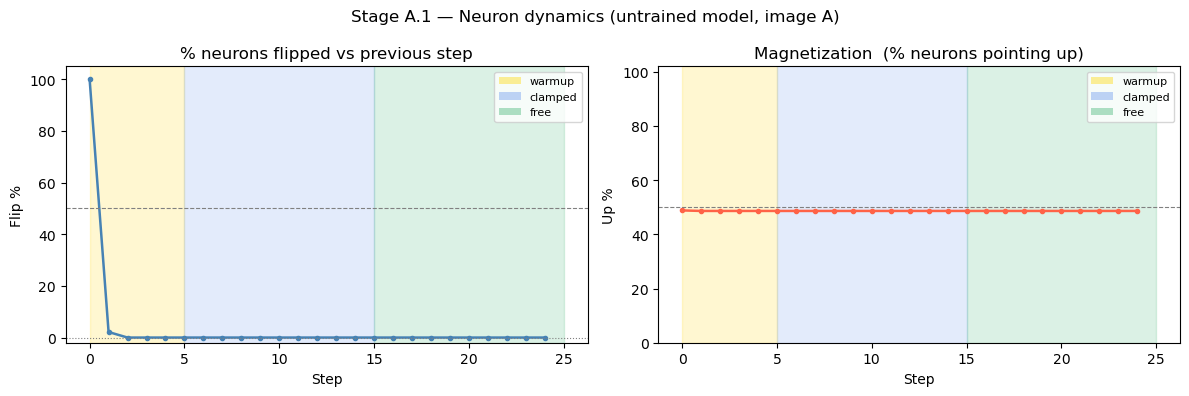

In [38]:

# ── Stage A.1 — Neuron-level dynamics: flip% and magnetization ─────────────
# Uses the same untrained model from A.1 (orch was built just above).

_s_track = state.init(x_A_flat, y_A1)
key, _rng_track = jax.random.split(key)

flip_A1, mag_A1, phases_A1, _ = run_full_dynamic_tracked(
    orch, _s_track, _rng_track,
    t_warmup=T_WARMUP, t_clamp=T_CLAMP, t_free=T_FREE,
)

print(f"Initial magnetization (before step 1) : n/a — first step shown at index 0")
print(f"Final flip% (last free step) : {flip_A1[-1]*100:.1f}%")
print(f"Final magnetization          : {mag_A1[-1]*100:.1f}%  (up neurons)")

plot_dynamic_tracking(flip_A1, mag_A1, phases_A1,
                      title="Stage A.1 — Neuron dynamics (untrained model, image A)")


In [25]:
# ── Stage A.2: convergence from multiple random initialisations ─────────────
# Run after N_UPDATES of training so J has learned something.
# (We use the untrained model here first as a baseline.)

N_INITS = 10
converged_list, n_iters_list, overlap_list = [], [], []

for i in range(N_INITS):
    key, rk = jax.random.split(key)
    s_i = state.init(x_A_flat, y_A1)
    # Random hidden state (no warmup bias)
    rand_hidden = jax.random.rademacher(rk, shape=s_i[1].shape, dtype=jnp.float32)
    s_i = s_i.replace_val(1, rand_hidden)
    key, rng_i = jax.random.split(key)
    conv, n, s_final = check_convergence(orch, s_i, rng_i, steps=30)
    converged_list.append(conv)
    n_iters_list.append(n)
    overlap_list.append(overlap(s_star, s_final))   # compare to reference s*

print("── Multi-init convergence (untrained) ──────────────────")
print(f"  Converged : {sum(converged_list)}/{N_INITS}")
print(f"  Avg iters : {np.mean(n_iters_list):.1f}")
print(f"  Overlap with reference s* | mean={np.mean(overlap_list):.3f}  std={np.std(overlap_list):.3f}")


── Multi-init convergence (untrained) ──────────────────
  Converged : 10/10
  Avg iters : 5.4
  Overlap with reference s* | mean=0.035  std=0.000


In [29]:
# ── Stage A.3: update loop — track attractor stability over updates ─────────
key, mk = jax.random.split(key)
state, orch, opt, opt_state = build_model(mk)

log = {k: [] for k in ["rel_dJ", "norm_J", "mean_abs_h", "frac_unstable",
                        "margin_prime", "margin_star", "overlap_ps"]}

for step in range(N_UPDATES):
    s = state.init(x_A_flat, y_A1)
    key, rng = jax.random.split(key)

    s, rng          = run_warmup(orch, s, rng)
    s_prime, rng    = run_clamped(orch, s, rng)
    s_star_i, rng   = run_free(orch, s_prime, rng)

    orch_before = orch
    key, rng_u = jax.random.split(key)
    orch, opt_state = do_update(orch, s_prime, opt, opt_state, rng_u)

    diag = update_diagnostics(orch_before, orch, s_prime)
    log["rel_dJ"].append(diag["rel_dJ"])
    log["norm_J"].append(diag["norm_J"])
    log["mean_abs_h"].append(diag["mean_abs_h"])
    log["frac_unstable"].append(diag["frac_unstable"])
    log["margin_prime"].append(soft_margin_hidden(s_prime))
    log["margin_star"].append(soft_margin_hidden(s_star_i))
    log["overlap_ps"].append(overlap(s_prime, s_star_i))

print(f"Update loop done ✓  ({N_UPDATES} steps)")
print(f"  Final margin s' : {log['margin_prime'][-1]:.3f}")
print(f"  Final margin s* : {log['margin_star'][-1]:.3f}")
print(f"  Final overlap   : {log['overlap_ps'][-1]:.3f}")
print(f"  Final ||J||     : {log['norm_J'][-1]:.1f}")


Update loop done ✓  (60 steps)
  Final margin s' : 1.000
  Final margin s* : 1.000
  Final overlap   : 1.000
  Final ||J||     : 23.2


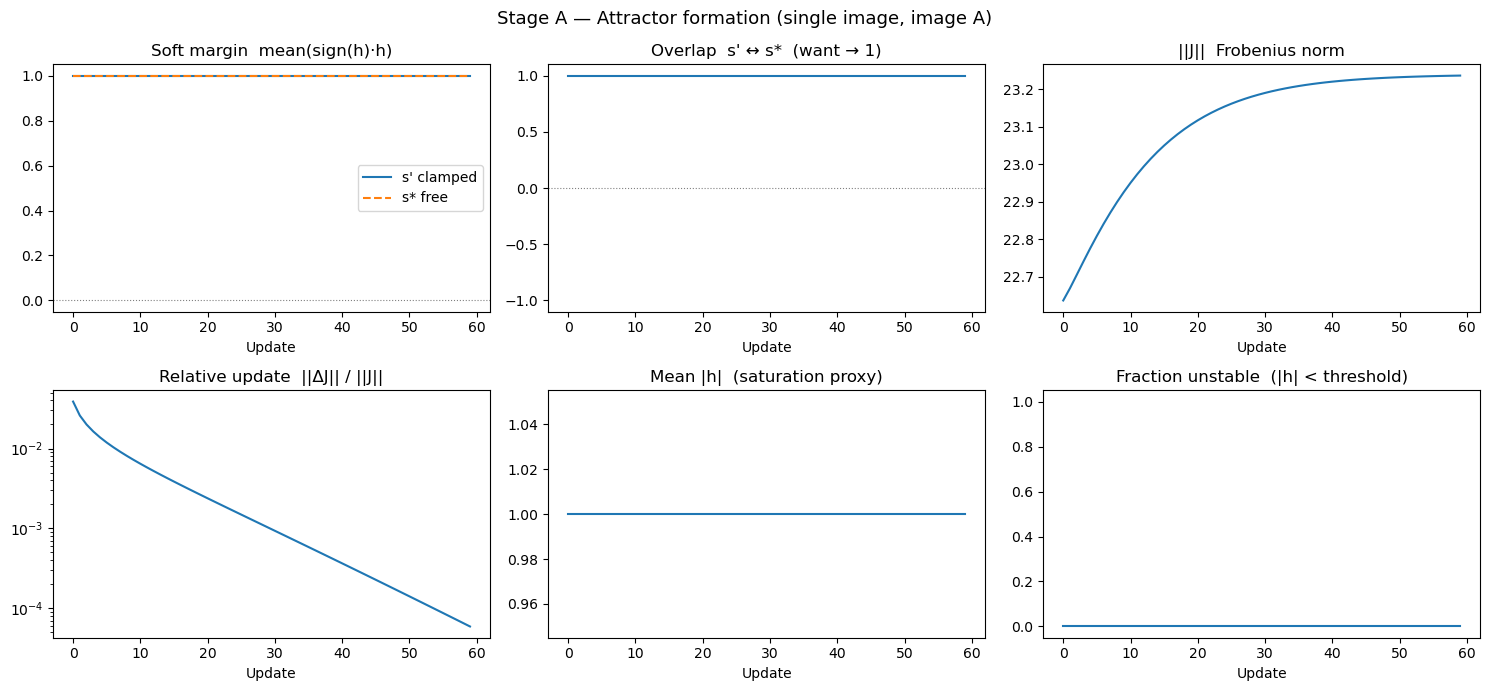

In [30]:
# ── Stage A plots ───────────────────────────────────────────────────────────
steps = np.arange(N_UPDATES)

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
fig.suptitle("Stage A — Attractor formation (single image, image A)", fontsize=13)

axes[0,0].plot(steps, log["margin_prime"], label="s' clamped")
axes[0,0].plot(steps, log["margin_star"],  label="s* free", ls="--")
axes[0,0].axhline(0, color="grey", lw=0.8, ls=":")
axes[0,0].set_title("Soft margin  mean(sign(h)·h)")
axes[0,0].set_xlabel("Update"); axes[0,0].legend()

axes[0,1].plot(steps, log["overlap_ps"])
axes[0,1].set_ylim(-1.1, 1.1)
axes[0,1].axhline(0, color="grey", lw=0.8, ls=":")
axes[0,1].set_title("Overlap  s' ↔ s*  (want → 1)")
axes[0,1].set_xlabel("Update")

axes[0,2].plot(steps, log["norm_J"])
axes[0,2].set_title("||J||  Frobenius norm")
axes[0,2].set_xlabel("Update")

axes[1,0].semilogy(steps, log["rel_dJ"])
axes[1,0].set_title("Relative update  ||ΔJ|| / ||J||")
axes[1,0].set_xlabel("Update")

axes[1,1].plot(steps, log["mean_abs_h"])
axes[1,1].set_title("Mean |h|  (saturation proxy)")
axes[1,1].set_xlabel("Update")

axes[1,2].plot(steps, log["frac_unstable"])
axes[1,2].set_ylim(-0.05, 1.05)
axes[1,2].set_title("Fraction unstable  (|h| < threshold)")
axes[1,2].set_xlabel("Update")

plt.tight_layout()
plt.show()


In [31]:
# ── Stage A.4: multi-init convergence AFTER training ───────────────────────
# Reference: run free dynamics from x_A_flat with standard init
s_ref = state.init(x_A_flat, None)
key, rng_ref = jax.random.split(key)
s_ref, rng_ref = run_free(orch, s_ref, rng_ref, steps=20)

converged_list, n_iters_list, overlap_list = [], [], []
for i in range(N_INITS):
    key, rk = jax.random.split(key)
    s_i = state.init(x_A_flat, None)
    rand_h = jax.random.rademacher(rk, shape=s_i[1].shape, dtype=jnp.float32)
    s_i = s_i.replace_val(1, rand_h)
    key, rng_i = jax.random.split(key)
    conv, n, s_final = check_convergence(orch, s_i, rng_i, steps=30)
    converged_list.append(conv)
    n_iters_list.append(n)
    overlap_list.append(overlap(s_ref, s_final))

print("── Multi-init convergence (TRAINED model) ──────────────")
print(f"  Converged : {sum(converged_list)}/{N_INITS}")
print(f"  Avg iters : {np.mean(n_iters_list):.1f}")
print(f"  Overlap with reference | mean={np.mean(overlap_list):.3f}  std={np.std(overlap_list):.3f}")
print()
n_same_attr = sum(1 for v in overlap_list if abs(v) > 0.8)
print(f"  Strong alignment (|q|>0.8): {n_same_attr}/{N_INITS} inits → {'attractor exists ✓' if n_same_attr > N_INITS//2 else 'no clear attractor ✗'}")


── Multi-init convergence (TRAINED model) ──────────────
  Converged : 10/10
  Avg iters : 3.0
  Overlap with reference | mean=1.000  std=0.000

  Strong alignment (|q|>0.8): 10/10 inits → attractor exists ✓


---
## Stage B — One Image + Readout

**Goal:** Once the attractor exists, does the output layer predict the correct label?  
We continue training (same `orch` from Stage A) and monitor:
- binary readout accuracy
- soft output margin: `mean(sign(y) · h_out)`
- whether repeated updates improve or saturate


In [32]:
# ── Stage B helpers and additional updates ─────────────────────────────────

def readout_accuracy(s, y_true):
    """Binary accuracy for ±1 OVA labels using argmax of output state."""
    y_pred_idx = int(jnp.argmax(s[-1]))
    y_true_idx = int(jnp.argmax(y_true))
    return float(y_pred_idx == y_true_idx)

def output_soft_margin(s, y_true):
    """mean( sign(y_i) * h_out_i ) — confidence of the readout."""
    h_out = s[-1]          # pre-activation output (B, C)
    return float(jnp.mean(jnp.sign(y_true) * h_out))

# ── Continue training and track readout quality ─────────────────────────────
N_UPDATES_B = 60   # additional updates past Stage A

log_b = {k: [] for k in ["acc", "out_margin", "hidden_margin"]}

for step in range(N_UPDATES_B):
    s = state.init(x_A_flat, y_A1)
    key, rng = jax.random.split(key)
    s, rng         = run_warmup(orch, s, rng)
    s_prime, rng   = run_clamped(orch, s, rng)
    s_star_i, rng  = run_free(orch, s_prime, rng)

    key, rng_u = jax.random.split(key)
    orch, opt_state = do_update(orch, s_prime, opt, opt_state, rng_u)

    # Evaluate: run inference (no label clamping) on x_A
    s_eval = state.init(x_A_flat, None)
    key, rng_e = jax.random.split(key)
    s_eval, rng_e = run_free(orch, s_eval, rng_e, steps=T_FREE)
    key, rng_p = jax.random.split(key)
    s_eval, _ = orch.predict(s_eval, rng_p)

    log_b["acc"].append(readout_accuracy(s_eval, y_A1))
    log_b["out_margin"].append(output_soft_margin(s_eval, y_A1))
    log_b["hidden_margin"].append(soft_margin_hidden(s_eval))

print(f"Stage B done ✓")
print(f"  Final readout acc    : {log_b['acc'][-1]:.0%}")
print(f"  Final output margin  : {log_b['out_margin'][-1]:.3f}")
print(f"  Final hidden margin  : {log_b['hidden_margin'][-1]:.3f}")


Stage B done ✓
  Final readout acc    : 100%
  Final output margin  : 30.458
  Final hidden margin  : 1.000


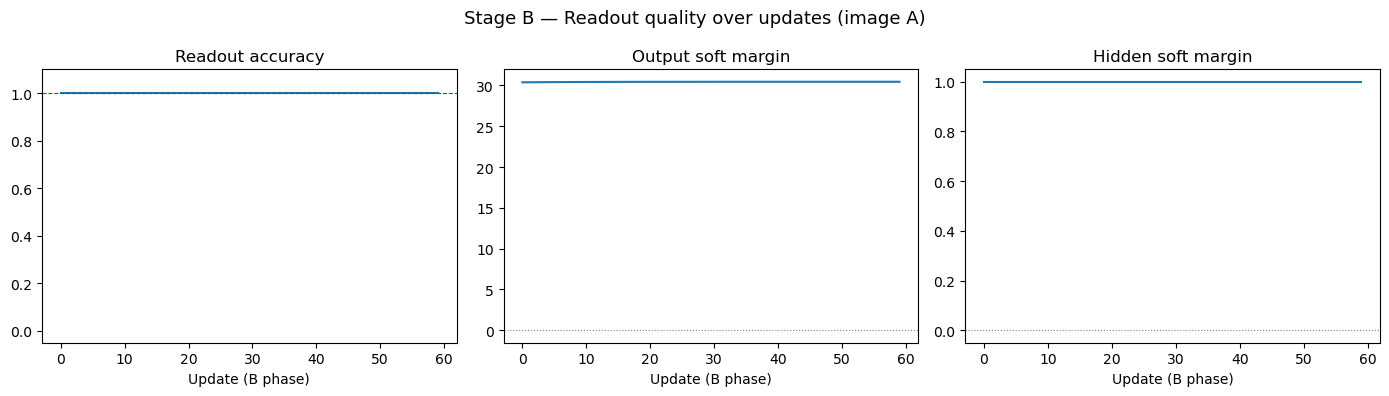

In [33]:
# ── Stage B plot ────────────────────────────────────────────────────────────
steps_b = np.arange(N_UPDATES_B)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Stage B — Readout quality over updates (image A)", fontsize=13)

axes[0].step(steps_b, log_b["acc"], where="post")
axes[0].set_ylim(-0.05, 1.1); axes[0].axhline(1, ls="--", color="green", lw=0.8)
axes[0].set_title("Readout accuracy"); axes[0].set_xlabel("Update (B phase)")

axes[1].plot(steps_b, log_b["out_margin"])
axes[1].axhline(0, color="grey", lw=0.8, ls=":")
axes[1].set_title("Output soft margin"); axes[1].set_xlabel("Update (B phase)")

axes[2].plot(steps_b, log_b["hidden_margin"])
axes[2].axhline(0, color="grey", lw=0.8, ls=":")
axes[2].set_title("Hidden soft margin"); axes[2].set_xlabel("Update (B phase)")

plt.tight_layout(); plt.show()


---
## Stage C — Basin of Attraction

**Goal:** How robust is the attractor learned for image A?  
We sample `N_BASIN` random initial states, run free dynamics,  
and measure:
- fraction that converge
- convergence time
- overlap with the trained attractor `s*`

A large fraction with high overlap indicates a **wide basin**.


── Basin of attraction (trained model) ─────────────────
  Converged            : 50/50  (100%)
  Avg convergence time : 3.0 steps
  Overlap w/ attractor | mean=1.000  std=0.000
  Strong alignment (|q|>0.7) : 50/50


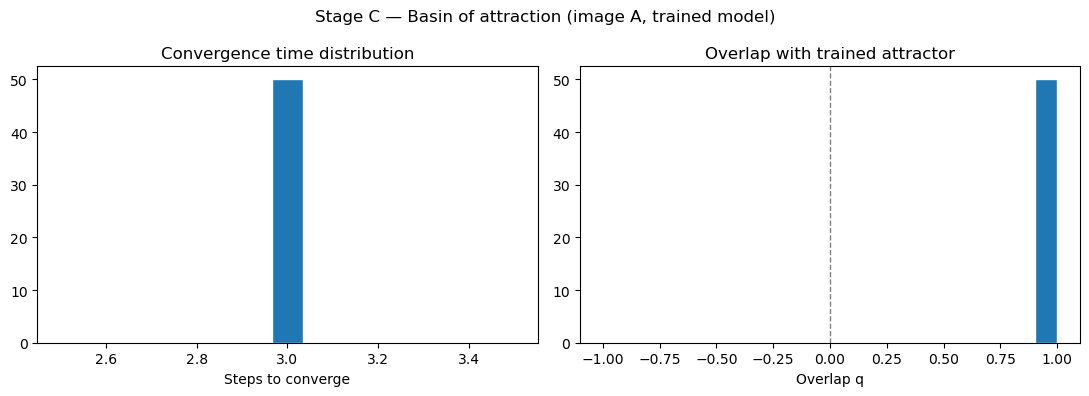

In [34]:
# ── Stage C: basin-of-attraction sweep ─────────────────────────────────────
N_BASIN = 50

# Reference attractor: input-seeded free dynamics
s_att = state.init(x_A_flat, None)
key, rng_att = jax.random.split(key)
s_att, _ = run_free(orch, s_att, rng_att, steps=30)

basin_conv, basin_iters, basin_overlap = [], [], []

for i in range(N_BASIN):
    key, rk = jax.random.split(key)
    s_i = state.init(x_A_flat, None)
    rand_h = jax.random.rademacher(rk, shape=s_i[1].shape, dtype=jnp.float32)
    s_i = s_i.replace_val(1, rand_h)
    key, rng_i = jax.random.split(key)
    conv, n_it, s_final = check_convergence(orch, s_i, rng_i, steps=40)
    basin_conv.append(conv)
    basin_iters.append(n_it)
    basin_overlap.append(overlap(s_att, s_final))

basin_frac = np.mean(basin_conv)
overlap_arr = np.array(basin_overlap)

print("── Basin of attraction (trained model) ─────────────────")
print(f"  Converged            : {int(sum(basin_conv))}/{N_BASIN}  ({basin_frac:.0%})")
print(f"  Avg convergence time : {np.mean(basin_iters):.1f} steps")
print(f"  Overlap w/ attractor | mean={overlap_arr.mean():.3f}  std={overlap_arr.std():.3f}")
print(f"  Strong alignment (|q|>0.7) : {np.sum(np.abs(overlap_arr)>0.7)}/{N_BASIN}")

# ── Basin plot ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Stage C — Basin of attraction (image A, trained model)", fontsize=12)

axes[0].hist(basin_iters, bins=15, edgecolor="white")
axes[0].set_title("Convergence time distribution"); axes[0].set_xlabel("Steps to converge")

axes[1].hist(overlap_arr, bins=20, range=(-1, 1), edgecolor="white")
axes[1].set_title("Overlap with trained attractor"); axes[1].set_xlabel("Overlap q")
axes[1].axvline(0, color="grey", lw=1, ls="--")

plt.tight_layout(); plt.show()


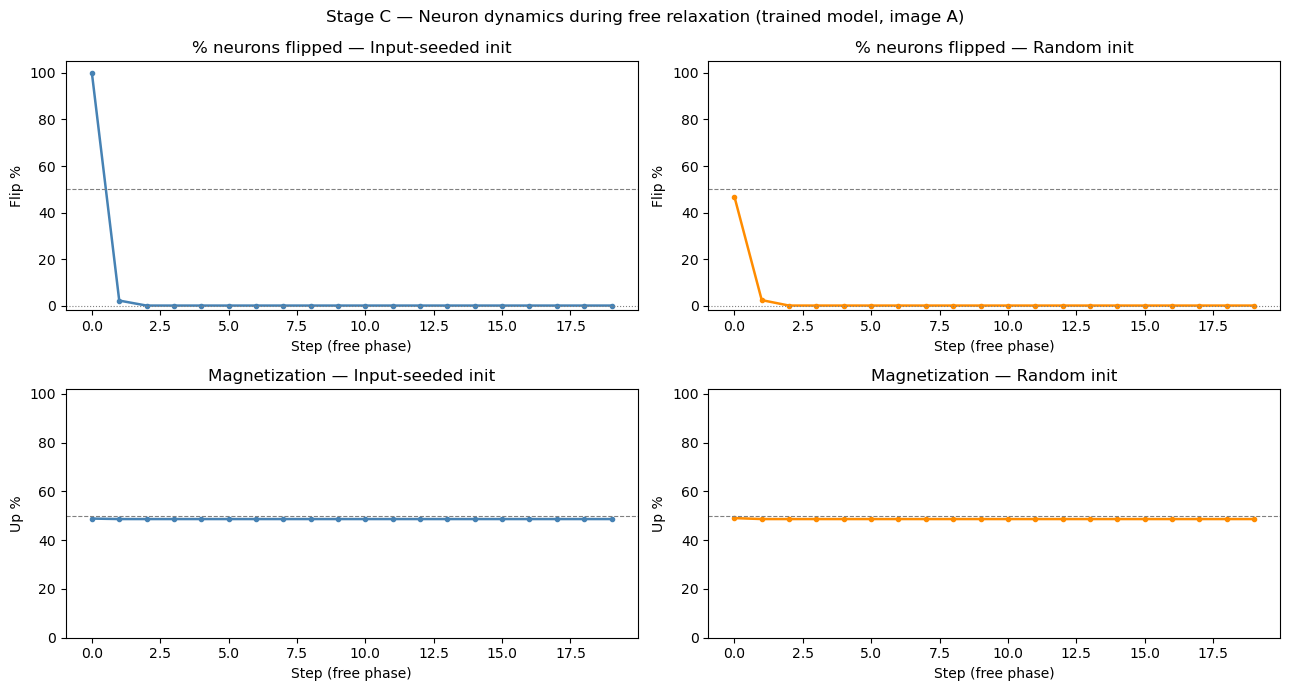

Seeded  — final flip%=0.0%  mag=48.6%
Random  — final flip%=0.0%  mag=48.6%


In [39]:

# ── Stage C — Neuron-level dynamics: flip% and magnetization ──────────────
# Two representative trajectories: (1) input-seeded init, (2) a random init.

# Trajectory 1: standard input-seeded initialisation
_s_c1 = state.init(x_A_flat, None)
key, _rng_c1 = jax.random.split(key)
flip_C_seed, mag_C_seed, phases_C_seed, _ = run_full_dynamic_tracked(
    orch, _s_c1, _rng_c1,
    t_warmup=0, t_clamp=0, t_free=T_FREE + 10,   # all free, longer to see convergence
)

# Trajectory 2: fully random initialisation (basin test)
key, _rk_c2 = jax.random.split(key)
_s_c2 = state.init(x_A_flat, None)
_rand_h_c2 = jax.random.rademacher(_rk_c2, shape=_s_c2[1].shape, dtype=jnp.float32)
_s_c2 = _s_c2.replace_val(1, _rand_h_c2)
key, _rng_c2 = jax.random.split(key)
flip_C_rand, mag_C_rand, phases_C_rand, _ = run_full_dynamic_tracked(
    orch, _s_c2, _rng_c2,
    t_warmup=0, t_clamp=0, t_free=T_FREE + 10,
)

# Plot side-by-side
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle("Stage C — Neuron dynamics during free relaxation (trained model, image A)", fontsize=12)

steps_c = np.arange(len(flip_C_seed))
for col, (flip, mag, label, color) in enumerate([
    (flip_C_seed, mag_C_seed, "Input-seeded init", "steelblue"),
    (flip_C_rand, mag_C_rand, "Random init",        "darkorange"),
]):
    axes[0, col].plot(steps_c, [f * 100 for f in flip], color=color, lw=1.8, marker='o', ms=3)
    axes[0, col].axhline(0,  color='grey', lw=0.8, ls=':')
    axes[0, col].axhline(50, color='grey', lw=0.8, ls='--')
    axes[0, col].set_ylim(-2, 105)
    axes[0, col].set_title(f"% neurons flipped — {label}")
    axes[0, col].set_xlabel("Step (free phase)"); axes[0, col].set_ylabel("Flip %")

    axes[1, col].plot(steps_c, [m * 100 for m in mag], color=color, lw=1.8, marker='o', ms=3)
    axes[1, col].axhline(50, color='grey', lw=0.8, ls='--')
    axes[1, col].set_ylim(0, 102)
    axes[1, col].set_title(f"Magnetization — {label}")
    axes[1, col].set_xlabel("Step (free phase)"); axes[1, col].set_ylabel("Up %")

plt.tight_layout()
plt.show()

print(f"Seeded  — final flip%={flip_C_seed[-1]*100:.1f}%  mag={mag_C_seed[-1]*100:.1f}%")
print(f"Random  — final flip%={flip_C_rand[-1]*100:.1f}%  mag={mag_C_rand[-1]*100:.1f}%")


---
## Stage D — Two-Image Interference (Forgetting vs Coexistence)

**Protocol:**
1. Train on image A for `N_PHASE_A` updates → establish attractor A
2. Then train **only** on image B for `N_PHASE_B` updates

**Track for both images at every step:**
- free-phase soft margin (hidden layer)
- readout accuracy
- overlap: `q(A,B) = ⟨s_A* · s_B*⟩`

**Expected outcomes:**
- Forgetting: margin A collapses after switching
- Coexistence: both margins stay positive  
- Collapse: both converge to the same attractor (`q → 1`)
- Instability: oscillations / no convergence


In [35]:
# ── Stage D: two-image interference ────────────────────────────────────────
N_PHASE_A = 60   # updates on image A
N_PHASE_B = 60   # updates on image B

# Fresh model
key, mk = jax.random.split(key)
state_d, orch_d, opt_d, opt_state_d = build_model(mk)

def eval_image(orch, state, x_flat, y_lbl, rng):
    """Return (soft_margin_hidden, readout_acc, free_state, rng)."""
    s = state.init(x_flat, None)
    s, rng = run_free(orch, s, rng, steps=T_FREE)
    key_p, rng = jax.random.split(rng)
    s, _ = orch.predict(s, key_p)
    return soft_margin_hidden(s), readout_accuracy(s, y_lbl), s, rng

log_d = {k: [] for k in ["margin_A", "margin_B", "acc_A", "acc_B",
                          "overlap_AB", "phase"]}

for step in range(N_PHASE_A + N_PHASE_B):
    phase = "A" if step < N_PHASE_A else "B"
    x_cur = x_A_flat if phase == "A" else x_B_flat
    y_cur = y_A1     if phase == "A" else y_B1

    s = state_d.init(x_cur, y_cur)
    key, rng = jax.random.split(key)
    s, rng       = run_warmup(orch_d, s, rng)
    s_prime, rng = run_clamped(orch_d, s, rng)
    key, rng_u   = jax.random.split(key)
    orch_d, opt_state_d = do_update(orch_d, s_prime, opt_d, opt_state_d, rng_u)

    # Evaluate both images without labels
    key, rng_eA = jax.random.split(key)
    key, rng_eB = jax.random.split(key)
    mA, accA, s_A_free, _ = eval_image(orch_d, state_d, x_A_flat, y_A1, rng_eA)
    mB, accB, s_B_free, _ = eval_image(orch_d, state_d, x_B_flat, y_B1, rng_eB)

    log_d["margin_A"].append(mA)
    log_d["margin_B"].append(mB)
    log_d["acc_A"].append(accA)
    log_d["acc_B"].append(accB)
    log_d["overlap_AB"].append(overlap(s_A_free, s_B_free))
    log_d["phase"].append(phase)

print("Stage D done ✓")
print(f"  End-of-A  | margin_A={log_d['margin_A'][N_PHASE_A-1]:.3f}  acc_A={log_d['acc_A'][N_PHASE_A-1]:.0%}")
print(f"  End-of-B  | margin_A={log_d['margin_A'][-1]:.3f}  margin_B={log_d['margin_B'][-1]:.3f}")
print(f"  Overlap A↔B at end : {log_d['overlap_AB'][-1]:.3f}")


Stage D done ✓
  End-of-A  | margin_A=1.000  acc_A=100%
  End-of-B  | margin_A=1.000  margin_B=1.000
  Overlap A↔B at end : 0.605


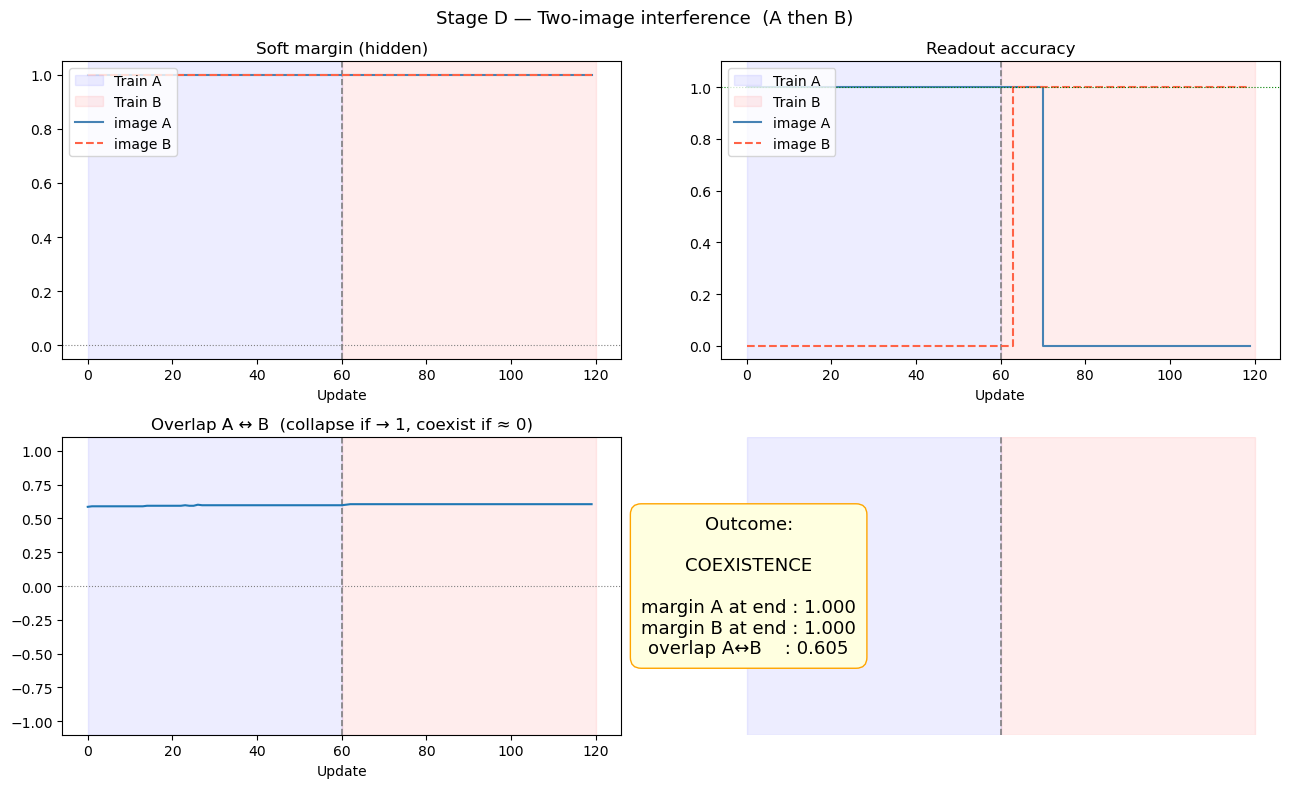

In [36]:
# ── Stage D plot ─────────────────────────────────────────────────────────────
steps_d = np.arange(N_PHASE_A + N_PHASE_B)
switch  = N_PHASE_A   # vertical line

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("Stage D — Two-image interference  (A then B)", fontsize=13)

def shade(ax):
    ax.axvspan(0, switch, alpha=0.07, color="blue", label="Train A")
    ax.axvspan(switch, steps_d[-1]+1, alpha=0.07, color="red", label="Train B")
    ax.axvline(switch, color="grey", lw=1.2, ls="--")

for ax in axes.ravel(): shade(ax)

axes[0,0].plot(steps_d, log_d["margin_A"], label="image A", color="steelblue")
axes[0,0].plot(steps_d, log_d["margin_B"], label="image B", ls="--", color="tomato")
axes[0,0].axhline(0, color="grey", lw=0.8, ls=":")
axes[0,0].set_title("Soft margin (hidden)"); axes[0,0].set_xlabel("Update")
axes[0,0].legend(loc="upper left")

axes[0,1].step(steps_d, log_d["acc_A"], label="image A", where="post", color="steelblue")
axes[0,1].step(steps_d, log_d["acc_B"], label="image B", where="post", ls="--", color="tomato")
axes[0,1].set_ylim(-0.05, 1.1); axes[0,1].axhline(1, ls=":", color="green", lw=0.8)
axes[0,1].set_title("Readout accuracy"); axes[0,1].set_xlabel("Update")
axes[0,1].legend(loc="upper left")

axes[1,0].plot(steps_d, log_d["overlap_AB"])
axes[1,0].axhline(0, color="grey", lw=0.8, ls=":")
axes[1,0].set_ylim(-1.1, 1.1)
axes[1,0].set_title("Overlap A ↔ B  (collapse if → 1, coexist if ≈ 0)")
axes[1,0].set_xlabel("Update")

# Diagnose outcome
m_A_end = log_d["margin_A"][-1]
m_B_end = log_d["margin_B"][-1]
ov_end  = log_d["overlap_AB"][-1]
if ov_end > 0.8:
    outcome = "COLLAPSE (same attractor)"
elif m_A_end > 0.5 and m_B_end > 0.5:
    outcome = "COEXISTENCE"
elif m_A_end < 0.1:
    outcome = "CATASTROPHIC FORGETTING of A"
else:
    outcome = "PARTIAL FORGETTING / INTERFERENCE"

axes[1,1].axis("off")
axes[1,1].text(0.5, 0.5,
    f"Outcome:\n\n{outcome}\n\n"
    f"margin A at end : {m_A_end:.3f}\n"
    f"margin B at end : {m_B_end:.3f}\n"
    f"overlap A↔B    : {ov_end:.3f}",
    ha="center", va="center", fontsize=13,
    bbox=dict(boxstyle="round,pad=0.6", facecolor="lightyellow", edgecolor="orange"))

plt.tight_layout(); plt.show()
